In [ ]:
# CELL 1: IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# CELL 2: DATA LOADING & EXPLORATORY SUMMARY
print("--- Loading Diabetes Dataset (Regression) ---")
data = load_diabetes()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # Continuous numerical values

print(f"Dataset Shape: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Target Feature (Disease Progression) Range: {y.min()} to {y.max()}")
print("\nFirst 5 rows of features:")
display(X.head())

--- Loading Diabetes Dataset (Regression) ---
Dataset Shape: 442 rows, 10 features
Target Feature (Disease Progression) Range: 25.0 to 346.0

First 5 rows of features:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
# CELL 3: PREPROCESSING
# Split the data (80% train, 20% test).
# Note: stratify=y is REMOVED because y is continuous, not categorical.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data AND transform it.
# Transform test data to prevent data leakage.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")

Data successfully split and scaled!


In [ ]:
# CELL 4: MODEL BUILDING
# Initialize a sequential model
model = Sequential([
    # Input layer and 1st Hidden Layer
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    # 2nd Hidden Layer
    Dense(32, activation='relu'),
    Dropout(0.2),

    # Output Layer
    # CHANGED: 1 neuron with 'linear' activation for continuous output
    Dense(1, activation='linear')
])

# Compile the model
# CHANGED: Loss is Mean Squared Error (mse), Metric is Mean Absolute Error (mae)
model.compile(optimizer='adam',
              loss='mse',
              metrics=['mae'])

print("--- Model Architecture ---")
model.summary()

--- Model Architecture ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# CELL 5: TRAINING WITH EARLY STOPPING
# Define EarlyStopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # We are monitoring the validation MSE
    patience=20,            # Wait 20 epochs for improvement
    restore_best_weights=True
)

print("--- Starting Training ---")
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    validation_split=0.2,
    callbacks=[early_stop],
    batch_size=32,
    verbose=1
)

--- Starting Training ---
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 251ms/step - loss: 31544.4941 - mae: 157.4437 - val_loss: 22240.3613 - val_mae: 133.1955
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 32570.9844 - mae: 164.7743 - val_loss: 22052.9512 - val_mae: 132.5232
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 29715.5293 - mae: 153.6546 - val_loss: 21849.0625 - val_mae: 131.7851
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 28555.3477 - mae: 149.4073 - val_loss: 21609.5273 - val_mae: 130.9223
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 29980.7852 - mae: 154.5419 - val_loss: 21317.0293 - val_mae: 129.8685
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 30181.4199 - mae: 155.7539 - val_loss: 20957.1230 - val_mae: 128.5764
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 29316.4805 - mae: 152.0205 - val_loss: 20516.7012 - val_mae: 126.9935
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 28899.3320 - mae: 1

--- Evaluating on Test Set ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step
Test Mean Squared Error (MSE): 2921.19
Test Mean Absolute Error (MAE): 43.36
Test R-squared Score: 0.4486



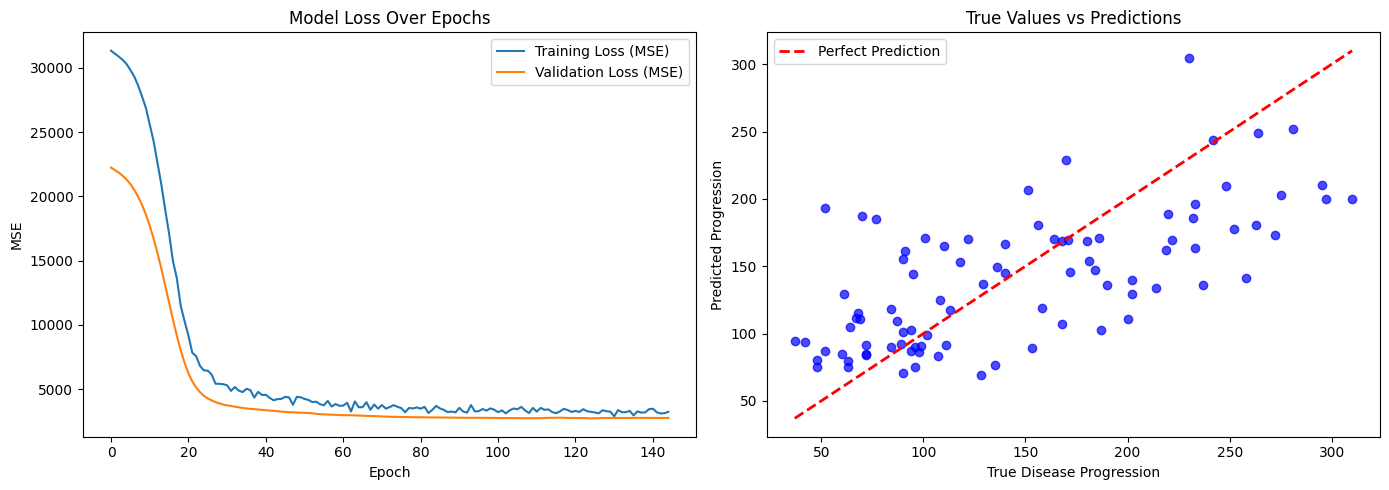

In [ ]:
# CELL 6: EVALUATION & VISUALIZATION
print("--- Evaluating on Test Set ---")
# Evaluate returns loss (MSE) and our chosen metric (MAE)
test_mse, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0)

# Generate predictions
y_pred = model.predict(X_test_scaled).flatten() # Flatten converts 2D output to 1D array

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

print(f"Test Mean Squared Error (MSE): {test_mse:.2f}")
print(f"Test Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"Test R-squared Score: {r2:.4f}\n")

# Plotting Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss (MSE)
axes[0].plot(history.history['loss'], label='Training Loss (MSE)')
axes[0].plot(history.history['val_loss'], label='Validation Loss (MSE)')
axes[0].set_title('Model Loss Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].legend()

# Plot True vs Predicted Scatter Plot
axes[1].scatter(y_test, y_pred, alpha=0.7, color='b')
# Draw a perfect prediction reference line (y = x)
min_val = min(np.min(y_test), np.min(y_pred))
max_val = max(np.max(y_test), np.max(y_pred))
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

axes[1].set_title('True Values vs Predictions')
axes[1].set_xlabel('True Disease Progression')
axes[1].set_ylabel('Predicted Progression')
axes[1].legend()

plt.tight_layout()
plt.show()